In [1]:
%pip install scikit-learn



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
df = pd.read_csv("Heart-disease-.csv")

In [7]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [8]:
# ==========================================================
# 2. LOAD DATA
# ==========================================================
df = pd.read_csv("Heart-disease-.csv")

# Drop index column if present
if df.columns[0].lower() in ["id", "index", "unnamed: 0"]:
    df = df.drop(columns=df.columns[0])

print("Columns in dataset:")
print(df.columns)


Columns in dataset:
Index(['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [ ]:
# ==========================================================
# CLEAN DATA 
# ==========================================================
# Replace common garbage strings with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.replace('\n', np.nan)
df = df.replace(' ', np.nan)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Strip whitespace from string cells
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Convert numeric-looking columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)


/var/folders/d6/9dybt9913rz9g61c15h_wcvw0000gn/T/ipykernel_18524/1370858694.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [10]:
# ==========================================================
# 3. CREATE BINARY TARGET (CLINICAL LOGIC)
# ==========================================================
# Original UCI dataset:
# num = 0  -> no heart disease
# num > 0  -> heart disease present

df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num"], inplace=True)

print("\nTarget distribution:")
print(df["target"].value_counts())



Target distribution:
target
1    509
0    411
Name: count, dtype: int64


In [11]:
# ==========================================================
# 4. SPLIT FEATURES AND TARGET
# ==========================================================
X = df.drop(columns=["target","dataset"])
y = df["target"]

print("\nFeature columns:")
print(X.columns)



Feature columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


In [12]:
# ==========================================================
# 5. DEFINE FEATURE TYPES
# ==========================================================
# Categorical features (medical categories)
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

# Numerical features = everything else
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("\nNumerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)



Numerical columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [13]:
# ==========================================================
# 6. PREPROCESSING PIPELINE
# ==========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [14]:
# ==========================================================
# 7. MODELS
# ==========================================================
logreg = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

rf = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ))
])

gnb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", GaussianNB())
])


In [15]:
# ==========================================================
# 8. CROSS-VALIDATION SETUP
# ==========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [16]:
# ==========================================================
# 9. EVALUATION FUNCTION
# ==========================================================
def evaluate_model(model, X, y, name):
    print("\n===============================")
    print(f" MODEL: {name}")
    print("===============================")

    y_pred = cross_val_predict(model, X, y, cv=kf)

    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    return accuracy, precision, recall, f1


In [17]:
# ==========================================================
# 10. RUN MODELS
# ==========================================================
results = {}

results["Logistic Regression"] = evaluate_model(logreg, X, y, "Logistic Regression")
results["Random Forest"] = evaluate_model(rf, X, y, "Random Forest")
results["Gaussian Naive Bayes"] = evaluate_model(gnb, X, y, "Gaussian Naive Bayes")



 MODEL: Logistic Regression
Confusion Matrix:
[[323  88]
 [ 77 432]]
Accuracy : 0.8207
Precision: 0.8308
Recall   : 0.8487
F1-score : 0.8397

 MODEL: Random Forest
Confusion Matrix:
[[320  91]
 [ 76 433]]
Accuracy : 0.8185
Precision: 0.8263
Recall   : 0.8507
F1-score : 0.8383

 MODEL: Gaussian Naive Bayes
Confusion Matrix:
[[372  39]
 [195 314]]
Accuracy : 0.7457
Precision: 0.8895
Recall   : 0.6169
F1-score : 0.7285


In [18]:
# ==========================================================
# 11. SUMMARY TABLE
# ==========================================================
summary = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [v[0] for v in results.values()],
    "Precision": [v[1] for v in results.values()],
    "Recall": [v[2] for v in results.values()],
    "F1-score": [v[3] for v in results.values()]
})

print("\n===============================")
print(" SUMMARY OF RESULTS")
print("===============================\n")
print(summary)



 SUMMARY OF RESULTS

                  Model  Accuracy  Precision    Recall  F1-score
0   Logistic Regression  0.820652   0.830769  0.848723  0.839650
1         Random Forest  0.818478   0.826336  0.850688  0.838335
2  Gaussian Naive Bayes  0.745652   0.889518  0.616896  0.728538


In [120]:
%pip install shap lime

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 3.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 1.8 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=c2090076a5689df3a0e15946abee81da3a965021a5532a4687e1156f6bc878e4
  Stored in directory: /Users/sanjanathippeswamy/Library/Caches/pip/wheels/7c/04/5c/157dc9106512a6c7a3065

In [19]:
best_model = rf   # your trained Random Forest pipeline
best_model.fit(X, y)


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
import shap
import numpy as np


# Get preprocessor
preprocessor = best_model.named_steps["preprocess"]

# Numerical features
num_features = preprocessor.transformers_[0][2]

# Categorical features after OneHotEncoding
cat_transformer = preprocessor.transformers_[1][1]
cat_features = cat_transformer.get_feature_names_out(
    preprocessor.transformers_[1][2]
)

# Combine feature names
feature_names = np.concatenate([num_features, cat_features])
print("Number of features:", len(feature_names))



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of features: 30


X shape: (920, 30)


 96%|=================== | 1775/1840 [00:16<00:00]       

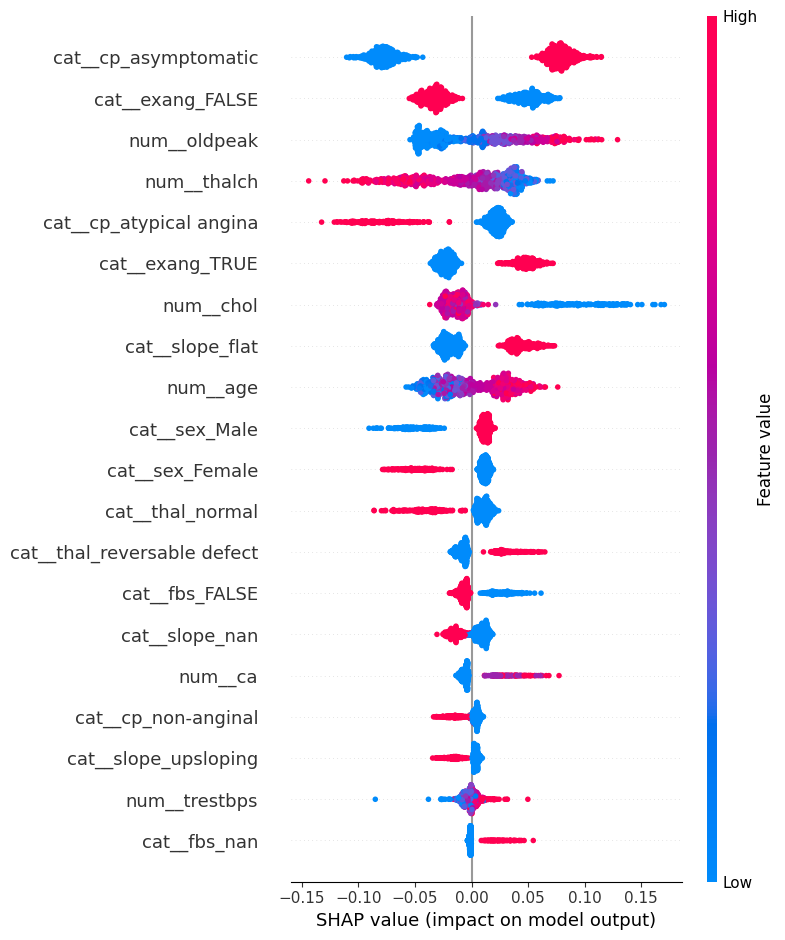

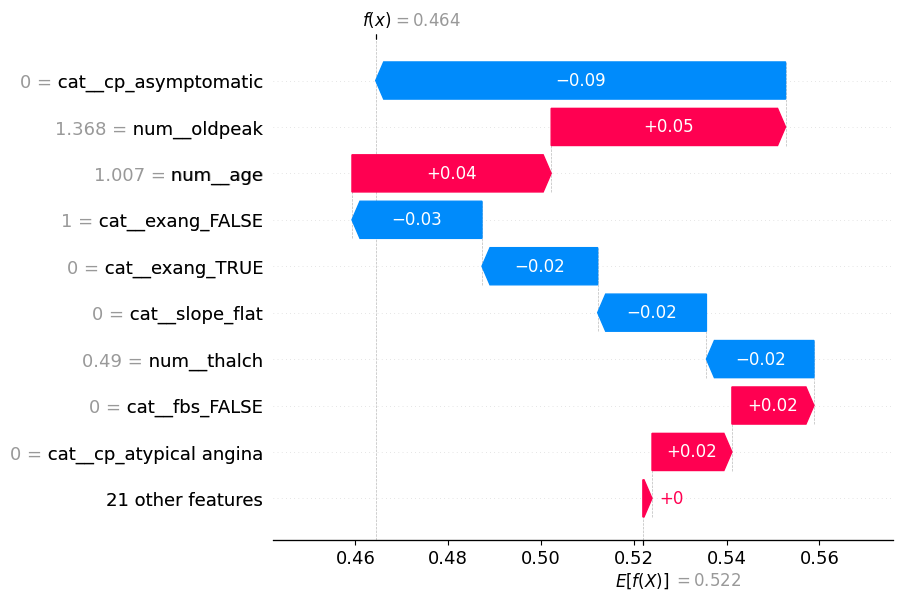

In [21]:


# Transform data
X_transformed = preprocessor.transform(X)
print("X shape:", X_transformed.shape)

# Create explainer
explainer = shap.Explainer(
    best_model.named_steps["clf"],
    X_transformed
)

# Compute SHAP values (FIX HERE)
shap_values = explainer(X_transformed, check_additivity=False)

# Feature names
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

# Global explanation
shap.summary_plot(
    shap_values[:, :, 1],      # <-- class 1
    X_transformed,
    feature_names=feature_names
)


# Local explanation (waterfall) – create a proper Explanation object
expl = shap.Explanation(
    values=shap_values[0, :, 1],          # SHAP values for sample 0, class 1
    base_values=explainer.expected_value[1],  # base value for class 1
    data=X_transformed[0],                # feature values of sample 0
    feature_names=feature_names
)

# Waterfall plot
shap.plots.waterfall(expl)


In [22]:
best_model.named_steps


{'preprocess': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['age', 'trestbps', 'chol', 'thalch',
                                   'oldpeak', 'ca']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                   'slope', 'thal'])]),
 'clf': RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)}

In [28]:
%pip install lime
%pip install --upgrade lime



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from lime.lime_tabular import LimeTabularExplainer


In [23]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

X_raw_encoded = X.copy()

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_raw_encoded[col] = le.fit_transform(X_raw_encoded[col])
    label_encoders[col] = le

X_np_raw_encoded = X_raw_encoded.to_numpy()




In [32]:
%pip install --upgrade ipython notebook
from IPython.display import display, HTML



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML

categorical_indices = [X.columns.get_loc(c) for c in categorical_cols]

lime_explainer = LimeTabularExplainer(
    training_data=X_np_raw_encoded,
    feature_names=X.columns.tolist(),
    categorical_features=categorical_indices,
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

# Wrapper predict function
def pipeline_predict(x):
    df = pd.DataFrame(x, columns=X.columns)
    # Apply label encoders before pipeline
    for col in categorical_cols:
        df[col] = label_encoders[col].inverse_transform(df[col].astype(int))
    return best_model.predict_proba(df)

# Explain first instance
i = 0
lime_exp = lime_explainer.explain_instance(
    data_row=X_np_raw_encoded[i],
    predict_fn=pipeline_predict,
    num_features=13
)

# Display LIME explanation
display(HTML(lime_exp.as_html()))


In [34]:
%pip show ipython


Name: ipython
Version: 9.9.0
Summary: IPython: Productive Interactive Computing
Home-page: https://ipython.org
Author: The IPython Development Team
Author-email: ipython-dev@python.org
License-Expression: BSD-3-Clause
Location: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages
Requires: decorator, ipython-pygments-lexers, jedi, matplotlib-inline, pexpect, prompt_toolkit, pygments, stack_data, traitlets
Required-by: ipykernel
Note: you may need to restart the kernel to use updated packages.


In [37]:
# Train model
best_model.fit(X, y)

# Save model
import joblib
joblib.dump(best_model, "rf")


['rf']

In [1]:
%pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 1.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 2.1 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 1.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [streamlit]14 [streamlit]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
